In [1]:
import pandas as pd
titanic_data = pd.read_csv("./titanic3.csv")
titanic_data.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [2]:
titanic_data.describe()

,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881138,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413493,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.170000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


In [3]:
titanic_data = pd.concat([titanic_data,
                          pd.get_dummies(titanic_data['sex']),
                          pd.get_dummies(titanic_data['embarked'],prefix="embark"),
                          pd.get_dummies(titanic_data['pclass'],prefix="class")], axis=1)

print(titanic_data.columns )
print(titanic_data['sex'])
print(titanic_data['male'])

Index(['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest', 'female',
       'male', 'embark_C', 'embark_Q', 'embark_S', 'class_1', 'class_2',
       'class_3'],
      dtype='object')
0       female
1         male
2       female
3         male
4       female
         ...  
1304    female
1305    female
1306      male
1307      male
1308      male
Name: sex, Length: 1309, dtype: object
0       0
1       1
2       0
3       1
4       0
       ..
1304    0
1305    0
1306    1
1307    1
1308    1
Name: male, Length: 1309, dtype: uint8


In [4]:
titanic_data.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,...,body,home.dest,female,male,embark_C,embark_Q,embark_S,class_1,class_2,class_3
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,...,NaN,"St Louis, MO",1,0,0,0,1,1,0,0
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,...,NaN,"Montreal, PQ / Chesterville, ON",0,1,0,0,1,1,0,0
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,...,NaN,"Montreal, PQ / Chesterville, ON",1,0,0,0,1,1,0,0
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,...,135.0,"Montreal, PQ / Chesterville, ON",0,1,0,0,1,1,0,0
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,...,NaN,"Montreal, PQ / Chesterville, ON",1,0,0,0,1,1,0,0


In [5]:
#填充None值
titanic_data["age"] = titanic_data["age"].fillna(titanic_data["age"].mean())
titanic_data["fare"] = titanic_data["fare"].fillna(titanic_data["fare"].mean())

In [6]:
titanic_data = titanic_data.drop(['name','ticket','cabin','boat','body','home.dest','sex','embarked','pclass'], axis=1)
print(titanic_data.columns )

Index(['survived', 'age', 'sibsp', 'parch', 'fare', 'female', 'male',
       'embark_C', 'embark_Q', 'embark_S', 'class_1', 'class_2', 'class_3'],
      dtype='object')


In [7]:
#分离样本和标签
labels = titanic_data["survived"].to_numpy()

titanic_data = titanic_data.drop(['survived'], axis=1)
data = titanic_data.to_numpy()

#样本的属性名称
feature_names = list(titanic_data.columns)

In [8]:
import numpy as np
#划分数据集
np.random.seed(10)
train_indices = np.random.choice(len(labels), int(0.7*len(labels)), replace=False)
test_indices = list(set(range(len(labels))) - set(train_indices))
train_features = data[train_indices]
train_labels = labels[train_indices]
test_features = data[test_indices]
test_labels = labels[test_indices]

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class Mish(nn.Module):#Mish激活函数
    def __init__(self):
        super().__init__()
        print("Mish activation loaded...")
    def forward(self,x):
        x = x * (torch.tanh(F.softplus(x)))
        return x


torch.manual_seed(0)  #设置随机种子

class ThreelinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(12, 12)
        self.mish1 = Mish()
        self.linear2 = nn.Linear(12, 8)
        self.mish2 = Mish()
        self.linear3 = nn.Linear(8, 2)
        self.softmax = nn.Softmax(dim=1)
        self.criterion = nn.CrossEntropyLoss() #定义交叉熵函数

    def forward(self, x): #定义一个全连接网络
        lin1_out = self.linear1(x)
        out1 = self.mish1(lin1_out)
        out2 = self.mish2(self.linear2(out1))

        return self.softmax(self.linear3(out2))
    

    def getloss(self,x,y): #实现LogicNet类的损失值计算接口
        y_pred = self.forward(x)
        loss = self.criterion(y_pred,y)#计算损失值得交叉熵
        return loss

Mish activation loaded...
Mish activation loaded...
Epoch 1/200 => Loss: 0.72
Epoch 21/200 => Loss: 0.55
Epoch 41/200 => Loss: 0.52
Epoch 61/200 => Loss: 0.49
Epoch 81/200 => Loss: 0.49
Epoch 101/200 => Loss: 0.48
Epoch 121/200 => Loss: 0.48
Epoch 141/200 => Loss: 0.48
Epoch 161/200 => Loss: 0.48
Epoch 181/200 => Loss: 0.47


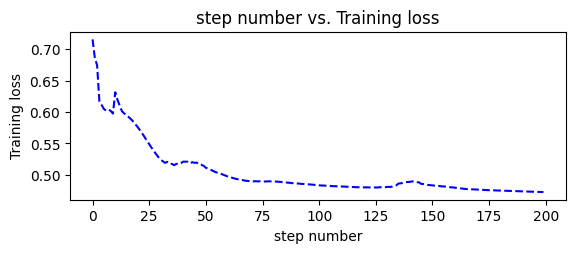

In [10]:
import os
from scipy import stats
import matplotlib.pyplot as plt
net = ThreelinearModel()


num_epochs = 200

optimizer = torch.optim.Adam(net.parameters(), lr=0.04)



input_tensor = torch.from_numpy(train_features).type(torch.FloatTensor)
label_tensor = torch.from_numpy(train_labels)

losses = []#定义列表，用于接收每一步的损失值
for epoch in range(num_epochs): 
    loss = net.getloss(input_tensor,label_tensor)
    losses.append(loss.item())
    optimizer.zero_grad()#清空之前的梯度
    loss.backward()#反向传播损失值
    optimizer.step()#更新参数
    if epoch % 20 == 0:
        print ('Epoch {}/{} => Loss: {:.2f}'.format(epoch+1, num_epochs, loss.item()))

def moving_average(a, w=10):#定义函数计算移动平均损失值
    if len(a) < w:
        return a[:]
    return [val if idx < w else sum(a[(idx-w):idx])/w for idx, val in enumerate(a)]
        
        
avgloss= moving_average(losses) #获得损失值的移动平均值
plt.figure(1)
plt.subplot(211)
plt.plot(range(len(avgloss)), avgloss, 'b--')
plt.xlabel('step number')
plt.ylabel('Training loss')
plt.title('step number vs. Training loss')
plt.show()


os.makedirs('models', exist_ok=True)
torch.save(net.state_dict(), 'models/titanic_model.pt')    


In [11]:
out_probs = net(input_tensor).detach().numpy()
out_classes = np.argmax(out_probs, axis=1)
print("Train Accuracy:", sum(out_classes == train_labels) / len(train_labels))

#测试模型
test_input_tensor = torch.from_numpy(test_features).type(torch.FloatTensor)
out_probs = net(test_input_tensor).detach().numpy()
out_classes = np.argmax(out_probs, axis=1)
print("Test Accuracy:", sum(out_classes == test_labels) / len(test_labels))

Train Accuracy: 0.8351528384279476
Test Accuracy: 0.806615776081425
